# Run Log Results Plotter

Use this notebook to compare VFA, hybrid, or future simulation run logs. Add one or more folders to `RUN_LOGS`; each folder is searched recursively for `results.csv`, so a parent folder containing many experiments works directly.

In [19]:
from pathlib import Path
import os
import re
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "fomosim_matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

WORKSPACE_ROOT = Path.cwd()
while WORKSPACE_ROOT.name != "FOMOsim" and WORKSPACE_ROOT.parent != WORKSPACE_ROOT:
    WORKSPACE_ROOT = WORKSPACE_ROOT.parent

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

WORKSPACE_ROOT

Matplotlib is building the font cache; this may take a moment.


PosixPath('/Users/minasjovik/Projects/FOMOsim')

## Configuration

Edit `RUN_LOGS` and `METRICS`. You can give exact run folders, parent folders, direct `results.csv` paths, or glob patterns such as `run_logs/run_20260509_*`.

In [20]:
RUN_LOGS = [
    "run_logs/VFA_only_results",
    "run_logs/run_20260508_172054",
    "run_logs/run_20260508_172244",
    "run_logs/run_20260508_172429",
    "run_logs/run_20260508_172452",
    "run_logs/run_20260508_172523",
    "run_logs/run_20260508_173051",
    "run_logs/run_20260508_173149",
    "run_logs/run_20260509_081413",
    "run_logs/run_20260509_081421",
    "run_logs/run_20260509_104030",
    "run_logs/run_20260509_104504",
]

# Choose any columns from results.csv. Run the "Available columns" cell below to inspect options.
METRICS = ["service_level", "starvations", "congestions","total_depot_visits","total_fixed_on_site","total_picked_up_to_depot","total_functional_pickups","broken_ratio_end_onsite","broken_ratio_end_depot","functional_ratio_end"]

SORT_BY = "service_level"
OUTPUT_DIR = WORKSPACE_ROOT / "run_logs" / "plots" / "baseline_candidates"
SAVE_OUTPUTS = True
SAVE_SUMMARY_TABLE_CSV = True

METRIC_LABELS = {
    "service_level": "Service level",
    "starvations": "Starvations",
    "congestions": "Congestions",
    "avg_bike_km_driven": "Avg. bike km driven",
    "total_depot_visits": "Depot visits",
    "total_depot_deliveries": "Depot deliveries",
    "total_fixed_on_site": "Fixed on site",
    "total_picked_up_to_depot": "Picked up to depot",
    "total_depot_fixes": "Depot fixes",
    "total_functional_pickups": "Functional pickups",
    "total_functional_deliveries": "Functional deliveries",
    "broken_ratio_end_onsite": "End broken ratio onsite",
    "broken_ratio_end_depot": "End broken ratio depot",
    "functional_ratio_end": "End functional ratio",
}

## Helper Functions

In [21]:
def resolve_input(raw_path: str) -> list[Path]:
    raw_path = str(raw_path)
    base_pattern = raw_path if Path(raw_path).is_absolute() else str(WORKSPACE_ROOT / raw_path)
    matches = sorted(Path(p) for p in __import__("glob").glob(base_pattern))
    if not matches:
        matches = [Path(base_pattern)]
    return matches


def find_results_csv(run_logs: list[str]) -> list[Path]:
    paths = []
    for raw in run_logs:
        for path in resolve_input(raw):
            if path.is_file() and path.name == "results.csv":
                paths.append(path)
            elif path.is_dir():
                paths.extend(sorted(path.rglob("results.csv")))
            else:
                print(f"Warning: input not found, skipping: {raw}")
    return list(dict.fromkeys(paths))


def strip_known_suffixes(name: str) -> str:
    name = re.sub(r"_seed\d+.*$", "", name)
    name = re.sub(r"_TD_W\d+.*$", "", name)
    name = re.sub(r"_OS_W\d+.*$", "", name)
    name = re.sub(r"_EH_.*$", "", name)
    return name.strip("_")


def experiment_from_path(csv_path: Path) -> tuple[str, str]:
    folder = csv_path.parent.name
    if folder.startswith("hybrid_"):
        return "Hybrid", strip_known_suffixes(folder.removeprefix("hybrid_"))
    if folder.startswith("vfa_"):
        return "VFA", strip_known_suffixes(folder.removeprefix("vfa_"))

    try:
        first = pd.read_csv(csv_path, nrows=1)
        exp_name = str(first["exp_name"].iloc[0]) if "exp_name" in first else folder
    except Exception:
        exp_name = folder
    return "Unknown", strip_known_suffixes(exp_name)


def pretty_experiment(name: str) -> str:
    aliases = {
        "R4_NetTemporalAlternative": "Net temporal",
        "R6_BreadthDepth": "Squared count",
    }
    return aliases.get(name, name.replace("_", " "))


def load_results(run_logs: list[str]) -> pd.DataFrame:
    rows = []
    for csv_path in find_results_csv(run_logs):
        policy, experiment = experiment_from_path(csv_path)
        try:
            df = pd.read_csv(csv_path)
        except Exception as exc:
            print(f"Warning: could not read {csv_path}: {exc}")
            continue

        df["policy"] = policy
        df["experiment"] = experiment
        df["experiment_label"] = pretty_experiment(experiment)
        df["label"] = df["policy"] + ": " + df["experiment_label"]
        df["source"] = str(csv_path.relative_to(WORKSPACE_ROOT))
        rows.append(df)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def summarize_results(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    missing = [metric for metric in metrics if metric not in df.columns]
    if missing:
        raise ValueError(f"Missing metric columns: {missing}")

    grouped = df.groupby(["policy", "experiment", "experiment_label", "label"], dropna=False)
    parts = []
    for metric in metrics:
        stats = grouped[metric].agg(mean="mean", std="std", n="count").reset_index()
        stats["metric"] = metric
        parts.append(stats)
    return pd.concat(parts, ignore_index=True)


def ordered_labels(summary: pd.DataFrame, sort_by: str | None) -> list[str]:
    if sort_by and sort_by in set(summary["metric"]):
        ranking = summary[summary["metric"] == sort_by].sort_values("mean", ascending=False)
        return ranking["label"].tolist()
    return sorted(summary["label"].unique())


def wide_summary(summary: pd.DataFrame, metrics: list[str], sort_by: str | None) -> pd.DataFrame:
    labels = ordered_labels(summary, sort_by)
    mean_wide = summary.pivot(index="label", columns="metric", values="mean").reindex(labels)
    std_wide = summary.pivot(index="label", columns="metric", values="std").reindex(labels)
    n_values = summary[summary["metric"] == metrics[0]].set_index("label")["n"].reindex(labels)

    cols = []
    for metric in metrics:
        cols.extend([(metric, "mean"), (metric, "std")])

    out = pd.concat({"mean": mean_wide, "std": std_wide}, axis=1).swaplevel(axis=1)
    out = out.reindex(columns=pd.MultiIndex.from_tuples(cols))
    out.insert(0, ("n", ""), n_values)
    return out


def plot_metric_bars(summary: pd.DataFrame, metrics: list[str], sort_by: str | None = "service_level"):
    available_metrics = [m for m in metrics if m in set(summary["metric"])]
    labels = ordered_labels(summary, sort_by)

    fig_height = max(4.0, 0.38 * len(labels) * len(available_metrics))
    fig, axes = plt.subplots(1, len(available_metrics), figsize=(5.2 * len(available_metrics), fig_height), squeeze=False)
    y = np.arange(len(labels))

    for ax, metric in zip(axes[0], available_metrics):
        metric_summary = summary[summary["metric"] == metric].set_index("label").reindex(labels).reset_index()
        means = metric_summary["mean"].to_numpy(dtype=float)
        stds = metric_summary["std"].fillna(0.0).to_numpy(dtype=float)

        ax.barh(y, means, xerr=stds, color="#4C78A8", alpha=0.9)
        ax.set_title(METRIC_LABELS.get(metric, metric.replace("_", " ").title()))
        ax.invert_yaxis()
        ax.grid(axis="x", alpha=0.25)
        if metric == available_metrics[0]:
            ax.set_yticks(y, labels)
        else:
            ax.set_yticks(y, [])

        for yi, value in zip(y, means):
            if not np.isnan(value):
                txt = f"{value:.4f}" if abs(value) < 10 else f"{value:.0f}"
                ax.text(value, yi, f"  {txt}", va="center", fontsize=8)

    fig.tight_layout()
    return fig

## Load Results

In [22]:
results_csv = find_results_csv(RUN_LOGS)
print(f"Found {len(results_csv)} results.csv files")
for path in results_csv:
    print(path.relative_to(WORKSPACE_ROOT))

Found 18 results.csv files
run_logs/VFA_only_results/vfa_Imbalance_severity_squared_temporal_TD_W34_old_D504h_V1/results.csv
run_logs/VFA_only_results/vfa_Imbalance_severity_temporal_TD_W34_old_D504h_V1/results.csv
run_logs/VFA_only_results/vfa_Imbalance_squared_TD_W34_old_D504h_V1/results.csv
run_logs/VFA_only_results/vfa_Imbalance_squared_temporal_TD_W34_old_D504h_V1/results.csv
run_logs/VFA_only_results/vfa_Imbalance_temporal_TD_W34_old_D504h_V1/results.csv
run_logs/VFA_only_results/vfa_Squared_only_TD_W34_old_D504h_V1/results.csv
run_logs/VFA_only_results/vfa_Squared_temporal_TD_W34_old_D504h_V1/results.csv
run_logs/run_20260508_172054/hybrid_Imbalance_severity_squared_temporal_seed1000_bias_term_trans100_fsdiag25_g0.97_eps0_initbm2p5_TD_W34_old_D504h_V1/results.csv
run_logs/run_20260508_172244/hybrid_Imbalance_severity_temporal_seed1000_bias_term_trans100_fsdiag25_g0.97_eps0_initbm2p5_TD_W34_old_D504h_V1/results.csv
run_logs/run_20260508_172429/hybrid_Imbalance_squared_seed1000_bi

In [23]:
df = load_results(RUN_LOGS)
print(f"Loaded {len(df)} seed rows from {df['label'].nunique() if not df.empty else 0} experiments")
df.head()

Loaded 180 seed rows from 18 experiments


,seed,exp_name,alpha,duration_hours,total_runtime_s,service_level,avg_bike_km_driven,starvations,congestions,total_trips,bike_departures,bike_arrivals,total_depot_deliveries,total_depot_visits,total_fixed_on_site,total_picked_up_to_depot,total_depot_fixes,total_bikes_redistributed_from_depot,total_functional_pickups,total_functional_deliveries,broken_ratio_start_onsite,broken_ratio_start_depot,functional_ratio_start,broken_ratio_end_onsite,broken_ratio_end_depot,functional_ratio_end,broken_bikes_end_onsite,broken_bikes_end_depot,new_breakdowns_onsite,new_breakdowns_depot,restored_onsite,restored_depot,policy,experiment,experiment_label,label,source
0,42,Imbalance_severity_squared_temporal,0.0,504,40620,0.9094,398.1095,3922,1525,60092,56170,56171,152,41,178,152,152,143,6217,6363,0.0250,0.0329,0.9421,0.0521,0.1302,0.8177,40,100,200,216,178,143,VFA,Imbalance_severity_squared_temporal,Imbalance severity squared temporal,VFA: Imbalance severity squared temporal,run_logs/VFA_only_results/vfa_Imbalance_severi...
1,43,Imbalance_severity_squared_temporal,0.0,504,40620,0.9200,396.0447,3550,1258,60072,56522,56523,135,42,179,135,135,134,6308,6450,0.0235,0.0470,0.9295,0.0679,0.0966,0.8355,52,74,214,181,179,134,VFA,Imbalance_severity_squared_temporal,Imbalance severity squared temporal,VFA: Imbalance severity squared temporal,run_logs/VFA_only_results/vfa_Imbalance_severi...
2,44,Imbalance_severity_squared_temporal,0.0,504,40620,0.9101,397.1056,3819,1570,59914,56095,56097,164,41,180,164,164,164,6198,6362,0.0172,0.0385,0.9443,0.0432,0.1374,0.8194,33,105,202,237,180,164,VFA,Imbalance_severity_squared_temporal,Imbalance severity squared temporal,VFA: Imbalance severity squared temporal,run_logs/VFA_only_results/vfa_Imbalance_severi...
3,45,Imbalance_severity_squared_temporal,0.0,504,40620,0.9157,395.1265,3497,1519,59498,56001,56003,175,44,189,175,175,163,6106,6275,0.0303,0.0421,0.9276,0.0638,0.1107,0.8255,49,85,215,219,189,163,VFA,Imbalance_severity_squared_temporal,Imbalance severity squared temporal,VFA: Imbalance severity squared temporal,run_logs/VFA_only_results/vfa_Imbalance_severi...
4,46,Imbalance_severity_squared_temporal,0.0,504,40620,0.9199,395.4785,3608,1130,59172,55564,55561,149,43,177,147,149,141,6096,6243,0.0185,0.0278,0.9536,0.0469,0.1004,0.8527,36,77,199,197,177,141,VFA,Imbalance_severity_squared_temporal,Imbalance severity squared temporal,VFA: Imbalance severity squared temporal,run_logs/VFA_only_results/vfa_Imbalance_severi...


## Available Columns

In [24]:
pd.DataFrame({"column": df.columns})

,column
0,seed
1,exp_name
2,alpha
3,duration_hours
4,total_runtime_s
5,service_level
6,avg_bike_km_driven
7,starvations
8,congestions
9,total_trips


## Summary Table

In [25]:
summary = summarize_results(df, METRICS)
summary_table = wide_summary(summary, METRICS, SORT_BY)

formatters = {("n", ""): "{:.0f}"}
for metric in METRICS:
    formatters[(metric, "mean")] = "{:.4f}" if metric.endswith("ratio") or metric == "service_level" else "{:.4f}"
    formatters[(metric, "std")] = "{:.4f}" if metric.endswith("ratio") or metric == "service_level" else "{:.4f}"

summary_table.style.format(formatters).background_gradient(subset=[(SORT_BY, "mean")], cmap="Blues")

## Plot Selected Metrics

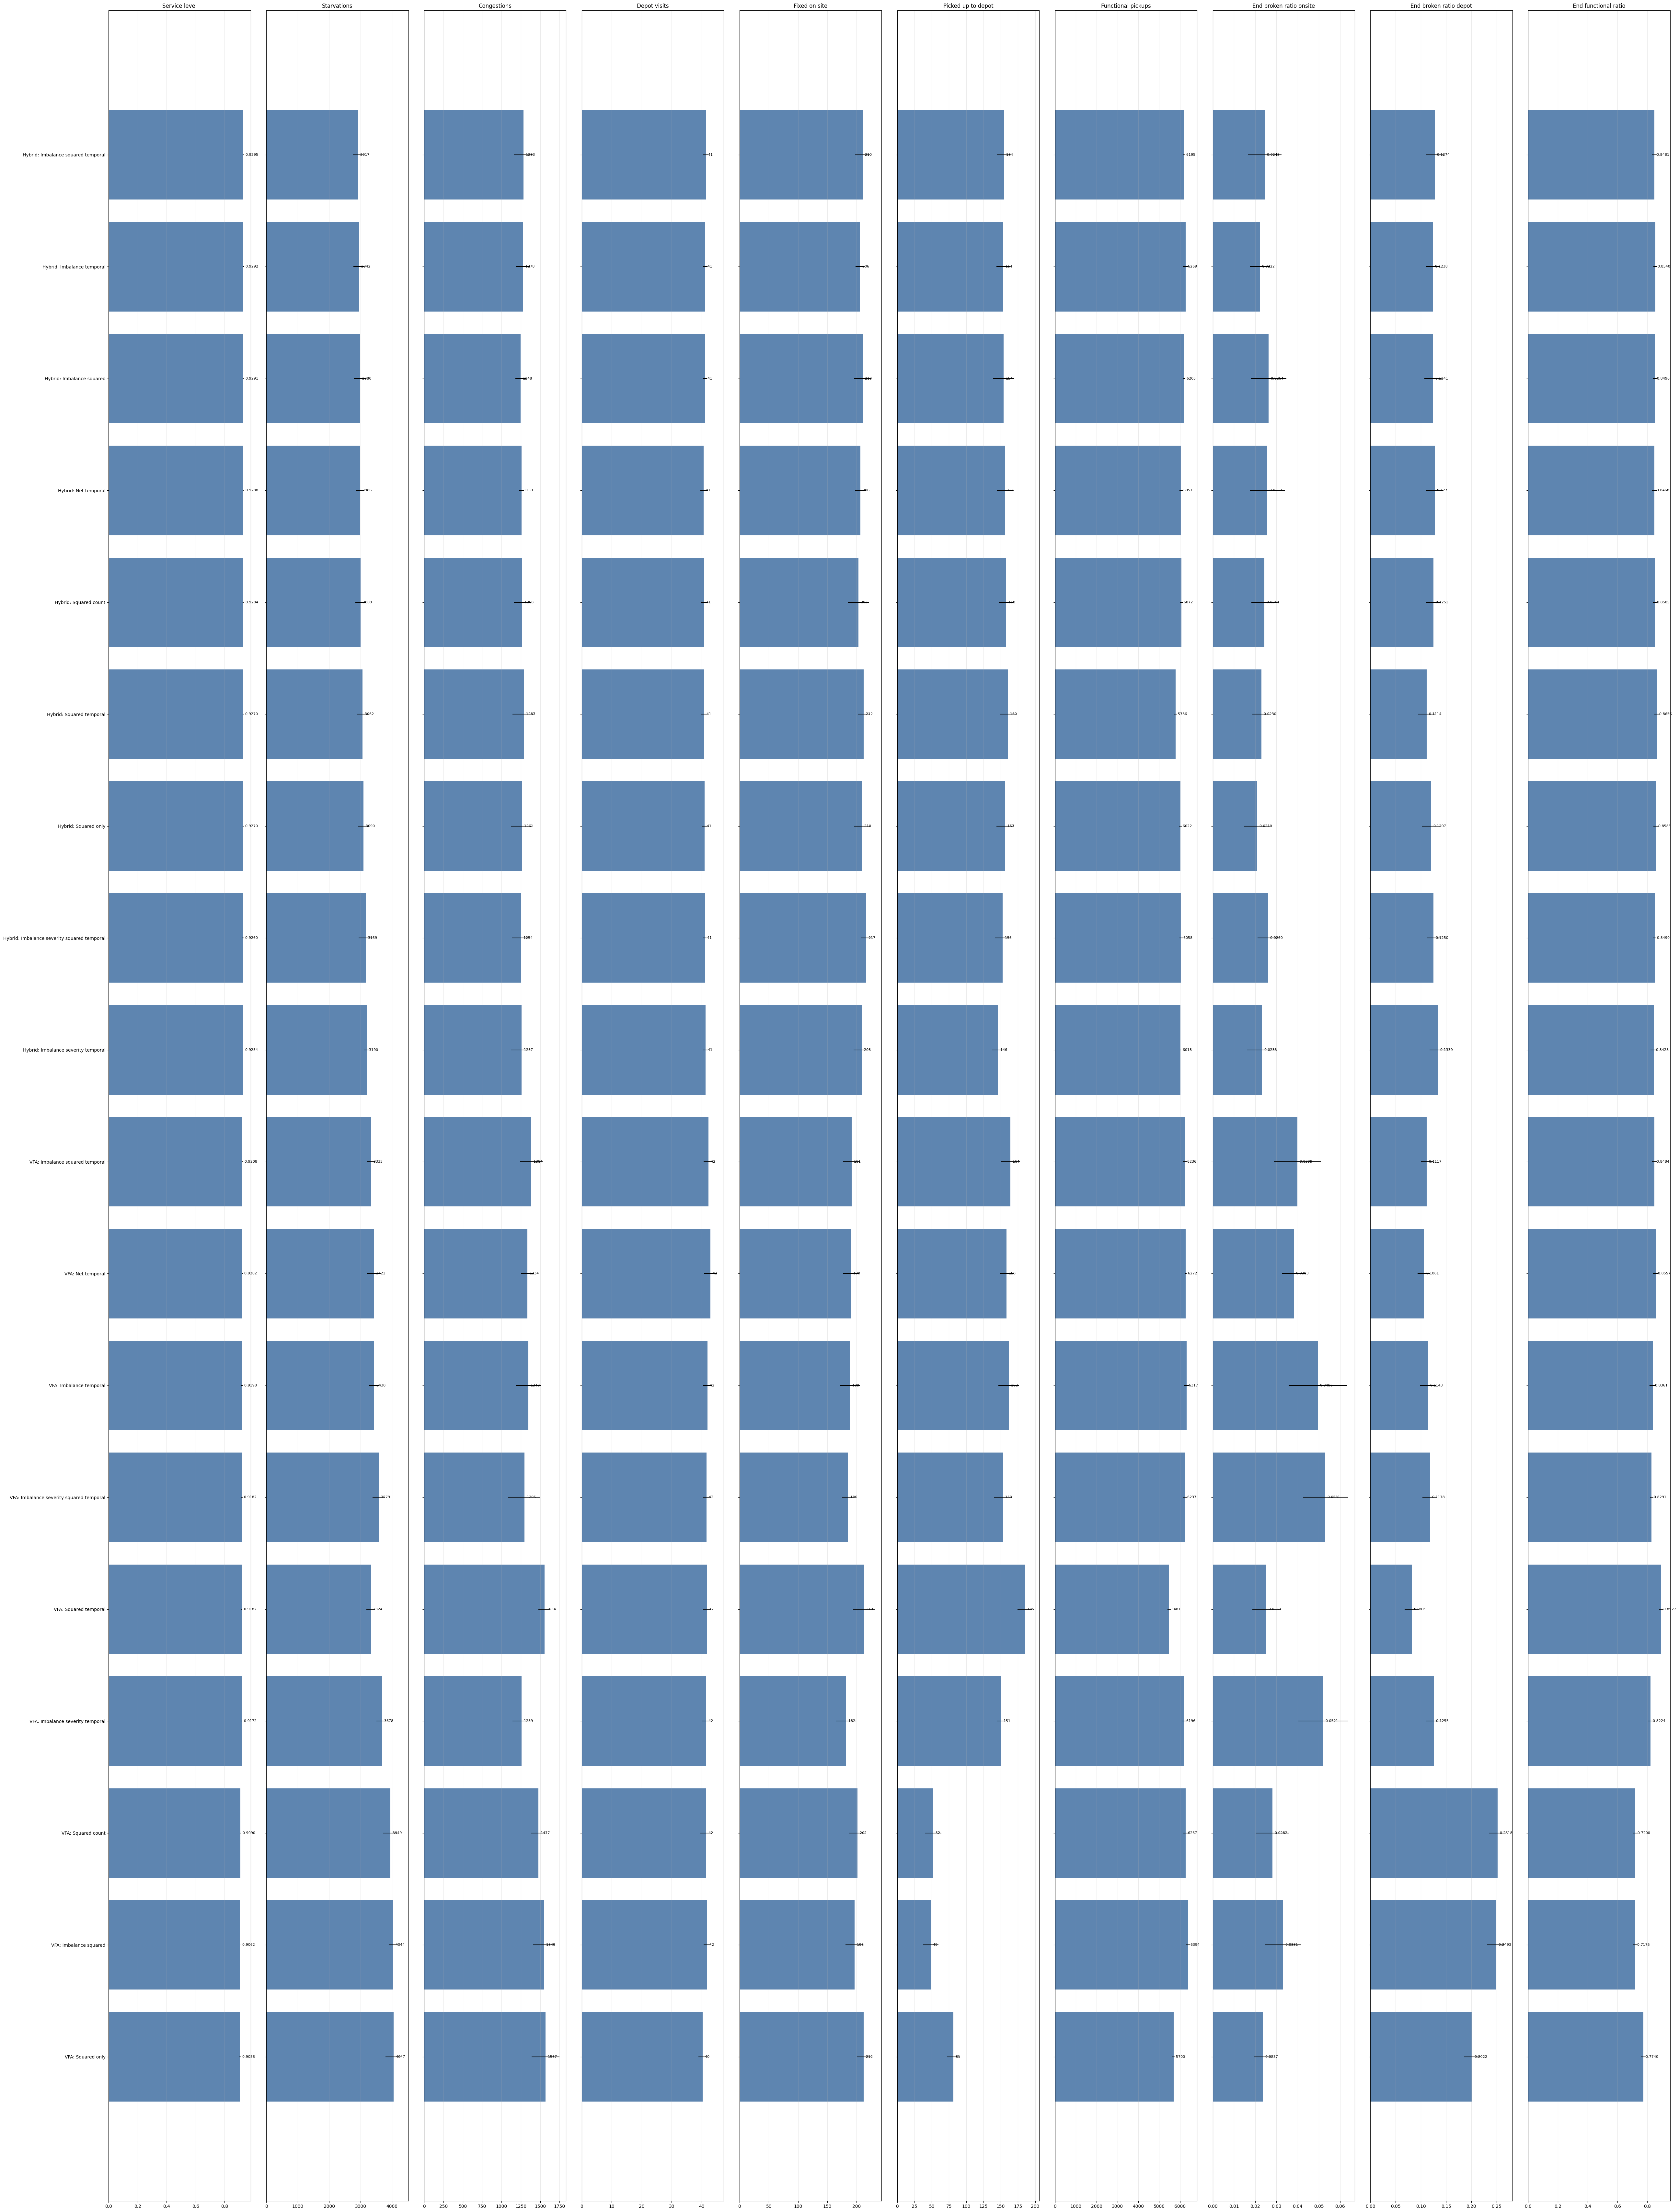

In [26]:
fig = plot_metric_bars(summary, METRICS, SORT_BY)
plt.show()

## Save Outputs

In [27]:
if SAVE_OUTPUTS or SAVE_SUMMARY_TABLE_CSV:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_SUMMARY_TABLE_CSV:
    summary_table_path = OUTPUT_DIR / "run_log_results_summary_table.csv"
    summary_table_csv = summary_table.copy()
    summary_table_csv.columns = [
        col[0] if col[1] == "" else f"{col[0]}_{col[1]}"
        for col in summary_table_csv.columns.to_flat_index()
    ]
    summary_table_csv.to_csv(summary_table_path)
    print(f"Saved summary table: {summary_table_path.relative_to(WORKSPACE_ROOT)}")

if SAVE_OUTPUTS:
    raw_path = OUTPUT_DIR / "run_log_results_raw.csv"
    summary_path = OUTPUT_DIR / "run_log_results_summary.csv"
    figure_path = OUTPUT_DIR / "run_log_results_comparison.png"

    df.to_csv(raw_path, index=False)
    summary.to_csv(summary_path, index=False)
    fig.savefig(figure_path, dpi=220, bbox_inches="tight")

    print(f"Saved raw data: {raw_path.relative_to(WORKSPACE_ROOT)}")
    print(f"Saved summary:  {summary_path.relative_to(WORKSPACE_ROOT)}")
    print(f"Saved figure:   {figure_path.relative_to(WORKSPACE_ROOT)}")

Saved summary table: run_logs/plots/baseline_candidates/run_log_results_summary_table.csv
Saved raw data: run_logs/plots/baseline_candidates/run_log_results_raw.csv
Saved summary:  run_logs/plots/baseline_candidates/run_log_results_summary.csv
Saved figure:   run_logs/plots/baseline_candidates/run_log_results_comparison.png
